In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

2022-09-05 18:52:49.350681: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-09-05 18:52:49.350720: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
crypto_currency = "BTC"
against_currency = "USD"
prediction_days = 60

In [3]:

# getting the data or price of bitcoin
start = dt.datetime(2016, 1, 1)
end = dt.datetime.now()

data = web.DataReader(f"{crypto_currency}-{against_currency}", "yahoo", start, end)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data["Close"].values.reshape(-1, 1))

In [4]:
# spliting the data in x and y train
x_train, y_train = [], []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x - prediction_days : x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [5]:
model = keras.models.load_model('btc_price_prediction.h5')

2022-09-05 18:52:52.775413: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2022-09-05 18:52:52.775446: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2022-09-05 18:52:52.775473: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (codespaces-af4c92): /proc/driver/nvidia/version does not exist
2022-09-05 18:52:52.775741: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
# getting the actual price of btc
test_start = dt.datetime(2020, 1, 1)
test_end = dt.datetime.now()
test_data = web.DataReader(f"{crypto_currency}-{against_currency}", "yahoo", test_start, test_end)
actual_prices = test_data["Close"].values

total_dataset = pd.concat((data["Close"], test_data["Close"]), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - prediction_days:].values
model_inputs = model_inputs.reshape(-1, 1)
model_inputs = scaler.fit_transform(model_inputs)

In [7]:
# spliting the data and predicting 
x_test = []

for x in range(prediction_days, len(model_inputs)):
    x_test.append(model_inputs[x - prediction_days : x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

prediction_prices = model.predict(x_test)
prediction_prices = scaler.inverse_transform(prediction_prices)

31/31 [==============================] - 2s 20ms/step


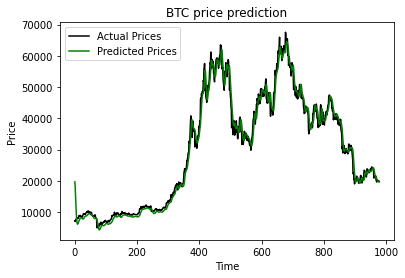

In [8]:
# ploting the result 
plt.plot(actual_prices, color="black", label="Actual Prices")
plt.plot(prediction_prices, color="green", label="Predicted Prices")
plt.title(f"{crypto_currency} price prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(loc="upper left")
plt.show()

In [9]:
real_data = [model_inputs[len(model_inputs) + 1 - prediction_days : len(model_inputs)+1,0]]
real_data = np.array(real_data)
real_data = np.reshape(real_data,(real_data.shape[0],real_data.shape[1],1))

In [10]:
prediction = model.predict(real_data)
prediction = scaler.inverse_transform(prediction)
prediction

1/1 [==============================] - 1s 894ms/step


array([[19671.936]], dtype=float32)